In [ ]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import seaborn as sns
from doctest import debug



###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study2.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
debug = 0

#Read in cleaned data
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'



print("Accomodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)



Accomodate columns: ['participant', 'free_texts', 'feedback', 'food_amount', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim_1', 'relevant_dim_2', 'irrelevant_dim', 'color_high', 'color_low', 'wing_high', 'wing_low', 'tail_high', 'tail_low', 'wing_discrete_slider.response', 'wing_direction_slider.response', 'wing_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'tail_discrete_slider.response', 'tail_direction_slider.response', 'tail_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'food_amount', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_wing', 'training_color', 'testing_categories', 'co

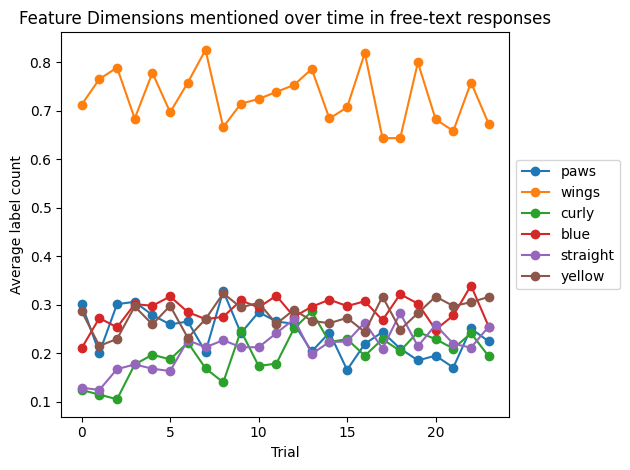

In [ ]:
def count_labels_over_time(free_text_list, word_labels):
    """
    free_text_list: list of free-text responses (strings) in order
    word_labels: dict mapping label -> list of words
    Returns a list of dicts (one per trial) with counts per label
    """
    counts_over_time = []

    for text in free_text_list:
        text_lower = text.lower()  # lowercase 
        counts = {label: 0 for label in word_labels}

        for label, words in word_labels.items():
            for word in words:
                counts[label] += text_lower.count(word)  # count occurrences
        counts_over_time.append(counts)

    return counts_over_time


word_labels = {
    'paws': ['paw', 'paws'],
    'wings': ['wing', 'wings'],
    'curly': ['curly'],
    'straight': ['straight'],
    'blue': ['blue'],
    'yellow': ['yellow']
}

all_counts = []

for idx, row in df_accommodate.iterrows():
    participant_id = row['participant'] 
    free_text_list = row['free_texts']
    #print(f"Processing participant {participant_id} with free-text responses: {free_text_list}")

    
    counts = count_labels_over_time(free_text_list, word_labels)
    #print(f"Counts for participant {participant_id}: {counts}")
    
    # Add participant ID and trial num
    for trial, count_dict in enumerate(counts):
        count_dict.update({'participant': participant_id, 'trial': trial})
        all_counts.append(count_dict)

df_counts = pd.DataFrame(all_counts)
df_grouped = df_counts.groupby('trial')[['paws','wings','curly', 'blue', 'straight', 'yellow']].mean()
df_grouped.plot(marker='o')
plt.xlabel('Trial')
plt.ylabel('Average label count')
plt.title('Feature Dimensions mentioned over time in free-text responses')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout() 
plt.show()
plt.show()


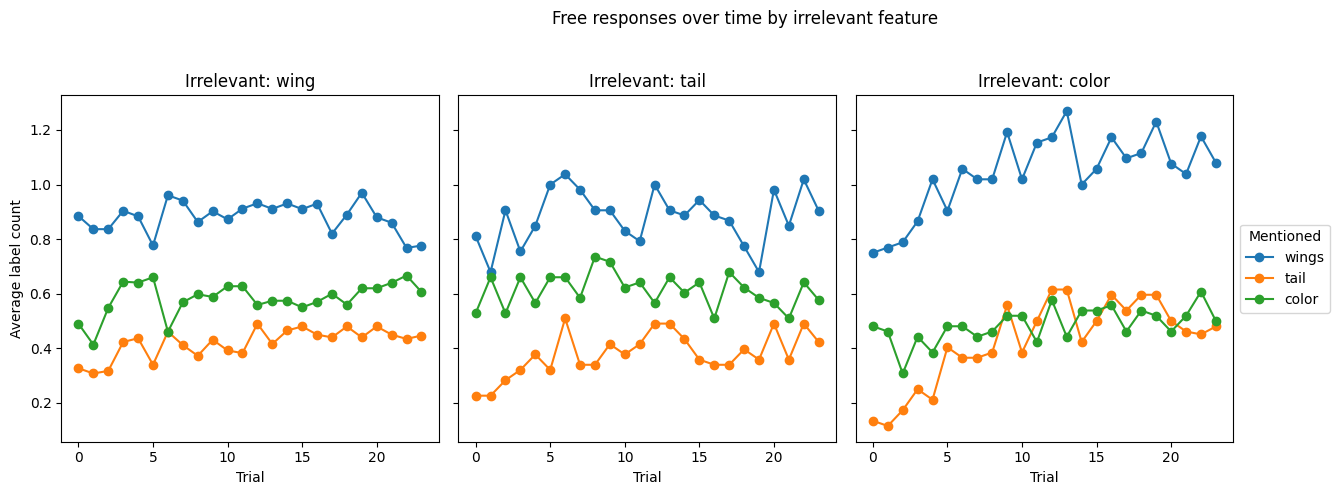

In [274]:
word_labels = {
    'wings': ['wings', 'tail'],
    'tail': ['curly', 'straight'],
    'color': ['blue', 'yellow']
}
def analyze_free_text_labels(df, word_labels, task_name='accommodate'):
    """
    df: DataFrame with columns ['participant', 'free_texts', 'irrelevant_dim']
    word_labels: dict mapping label -> list of words
    task_name: just for plot titles
    """
    all_counts = []

    for idx, row in df.iterrows():
        participant_id = row['participant']
        free_text_list = row['free_texts']
        irrelevant_feature = row['irrelevant_dim']

        counts = count_labels_over_time(free_text_list, word_labels)
        
        # Add participant ID, trial, and irrelevant_dim
        for trial, count_dict in enumerate(counts):
            count_dict.update({
                'participant': participant_id,
                'trial': trial,
                'irrelevant_dim': irrelevant_feature
            })
            all_counts.append(count_dict)

    # Convert to DataFrame
    df_counts = pd.DataFrame(all_counts)

    # Plot per irrelevant feature
    labels = list(word_labels.keys())
    irr_feats = df_counts['irrelevant_dim'].unique()
    fig, axes = plt.subplots(1, len(irr_feats), figsize=(15,5), sharey=True)

    for ax, irr_feat in zip(axes, irr_feats):
        df_grouped = df_counts[df_counts['irrelevant_dim'] == irr_feat] \
                        .groupby('trial')[labels].mean()
        df_grouped.plot(ax=ax, marker='o', legend=False)
        ax.set_title(f'Irrelevant: {irr_feat}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Average label count')

    plt.suptitle('Free responses over time by irrelevant feature')
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Mentioned')
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space for suptitle
    plt.show()

    return df_counts
df_counts = analyze_free_text_labels(df_accommodate, word_labels)


In [242]:
def show_participant_explanations(df, participant_id):
    row = df[df['participant'] == participant_id]

    if row.empty:
        print(f"No data for {participant_id}")
        return

    free_texts = row.iloc[0]['free_texts']

    if not isinstance(free_texts, list):
        free_texts = [free_texts]

    print(f"\nParticipant {participant_id} – Free-text explanations:\n")

    for trial, text in enumerate(free_texts):
        print(f"Trial {trial:02d}: {text}")

show_participant_explanations(df_accommodate, 220)


Participant 220 – Free-text explanations:

Trial 00: Blue sperks with tails eat about 6 chilis. 
Trial 01: The color and a straight tail seems to have no bearing on the amount of food sperks eat
Trial 02: The color or how the tail looks matters
Trial 03: The wings seem to be a factor in less food
Trial 04: The wings and the curly tail seem to be a factor in even less food
Trial 05: The curly tail affects the amount of food
Trial 06: The wings and the color and tail affect the food amount
Trial 07: A curly tail and wings affect the food
Trial 08: Color, wings, and curly tail affect the food
Trial 09: Straight tail and color increase the amount of food
Trial 10: Wings and curly tail decrease the food when blue
Trial 11: Wings and straight tail increase the food when blue
Trial 12: Curly tail decreases the food
Trial 13: Curly tail when yellow decreases the food
Trial 14: Wings and straight tail when yellow decreases food
Trial 15: Straight tail when yellow increases food
Trial 16: Strai

In [ ]:
PawWingExplanation = [1, 21, 31, 33, 35, 47, 63, 73, 74, 75, 86, 90, 109, 124, 139, 141, 142, 146, 151, 166, 172, 181, 184, 189, 194, 204, 213, 214, 216, 217, 218]
onlyatbeginning = [75, ]
Participantswithsemiexplanations = [16, 86]
LongerExamples = [20, 29, 30]

In [279]:
print(len(PawWingExplanation))

31


In [ ]:
explanationwords = ['find', 'search', 'fly', 'forage', 'energy', 'flying', 'flap', 'metabolism']
#give people preset explanations for flying/paws?
#Sometimes people give the functional explanation at the beginning but discard it by the end

In [243]:
PawWingExplanation = [
    1, 21, 31, 33, 35, 47, 63, 73, 74, 75, 86, 90, 109, 124,
    139, 141, 142, 146, 151, 166, 172, 181, 184, 189, 194,
    204, 213, 214, 216, 217, 218
]

df_accommodate['functional'] = df_accommodate['participant'].isin(
    PawWingExplanation
).map({True: 'functional', False: 'nonfunctional'})

In [248]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_tail', 'training_wing', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['food_amount'] = df_accommodate['food_amount'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['food_amount'] = df_predict['food_amount'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [252]:
import pandas as pd


#Loop through rows and determine model parameter score for each participant

participant_rows = []

for _, row in df_combined.iterrows():
    tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
    wing_yes = 1 if row['wing_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
    model_param_score = tail_yes + wing_yes + color_yes


    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'wing_high': row['wing_high'],
        'overfit': model_param_score == 3, #overfit if all 3 dimensions selected,
        'functional': row['functional']
    })

df_params = pd.DataFrame(participant_rows)

#Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")


overfit      False  True 
task                     
accommodate    116     93
predict        121     88
Chi-square = 0.156
df = 1
p-value = 0.6930


In [253]:
df_params['intuitive_relevance'] = (
    df_params['irrelevant_dim'] != 'wing'
).astype(int)

df_params['intuitive_direction'] = (
    df_params['wing_high'] == 'T'
).astype(int)

df_params['task'] = df_params['task'].astype('category')
df_params["overfit"] = df_params["overfit"].astype(int)
print(df_params)

     participant         task  model_param_score  conditionOrder  \
0              1  accommodate                  3             216   
1              2  accommodate                  2              31   
2              3  accommodate                  1             142   
3              4  accommodate                  1              18   
4              5  accommodate                  3              62   
..           ...          ...                ...             ...   
413          414      predict                  2             183   
414          415      predict                  2             178   
415          416      predict                  1             172   
416          417      predict                  3               4   
417          418      predict                  1              18   

    irrelevant_dim wing_high  overfit     functional  intuitive_relevance  \
0             wing         N        1     functional                    0   
1             tail         N 

In [256]:
summary = (
    df_params
    .groupby(
        ['task', 'functional', 'intuitive_relevance', 'intuitive_direction'],
        observed=True   
    )
    .agg(
        overfit_rate=('overfit', 'mean'),
        n=('overfit', 'size')
    )
    .reset_index()
)
print(summary)

          task     functional  intuitive_relevance  intuitive_direction  \
0  accommodate     functional                    0                    0   
1  accommodate     functional                    0                    1   
2  accommodate     functional                    1                    0   
3  accommodate     functional                    1                    1   
4  accommodate  nonfunctional                    0                    0   
5  accommodate  nonfunctional                    0                    1   
6  accommodate  nonfunctional                    1                    0   
7  accommodate  nonfunctional                    1                    1   

   overfit_rate   n  
0      0.625000   8  
1      0.500000   6  
2      0.714286   7  
3      0.500000  10  
4      0.454545  44  
5      0.478261  46  
6      0.304348  46  
7      0.452381  42  


In [258]:
summary_predict = (
    df_params[df_params['task'] == 'predict']
    .groupby(
        ['intuitive_relevance', 'intuitive_direction'],
        observed=True
    )
    .agg(
        overfit_rate=('overfit', 'mean'),
        n=('overfit', 'size')
    )
    .reset_index()
)
print(summary_predict)

   intuitive_relevance  intuitive_direction  overfit_rate   n
0                    0                    0      0.423077  52
1                    0                    1      0.384615  52
2                    1                    0      0.509434  53
3                    1                    1      0.365385  52


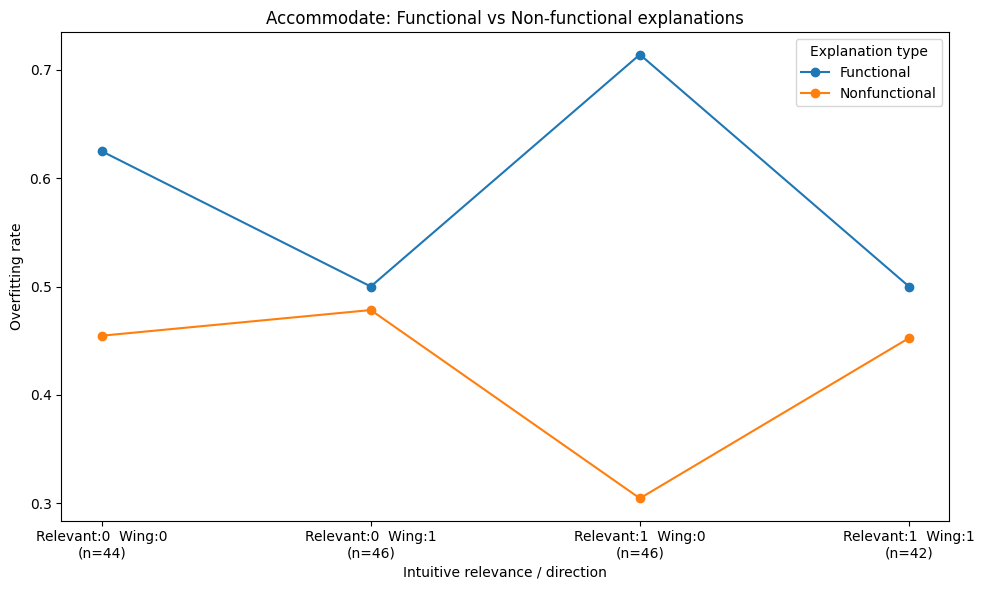

In [273]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only accommodators
subset = summary[summary['task'] == 'accommodate']

# Define x-axis groups (intuitive relevance × direction)
groups = (
    subset[['intuitive_relevance', 'intuitive_direction']]
    .drop_duplicates()
    .sort_values(['intuitive_relevance', 'intuitive_direction'])
    .reset_index(drop=True)
)

x = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(10, 6))

for func in ['functional', 'nonfunctional']:
    y = []
    n_labels = []

    for _, g in groups.iterrows():
        row = subset[
            (subset['functional'] == func) &
            (subset['intuitive_relevance'] == g['intuitive_relevance']) &
            (subset['intuitive_direction'] == g['intuitive_direction'])
        ]

        if row.empty:
            y.append(np.nan)
            n_labels.append(0)
        else:
            y.append(row['overfit_rate'].iloc[0])
            n_labels.append(row['n'].iloc[0])

    ax.plot(x, y, marker='o', label=func.capitalize())

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels([
    f"Relevant:{r}  Wing:{d}\n(n={n})"
    for r, d, n in zip(
        groups['intuitive_relevance'],
        groups['intuitive_direction'],
        n_labels
    )
])

ax.set_ylabel("Overfitting rate")
ax.set_xlabel("Intuitive relevance / direction")
ax.set_title("Accommodate: Functional vs Non-functional explanations")
ax.legend(title="Explanation type")

plt.tight_layout()
plt.show()

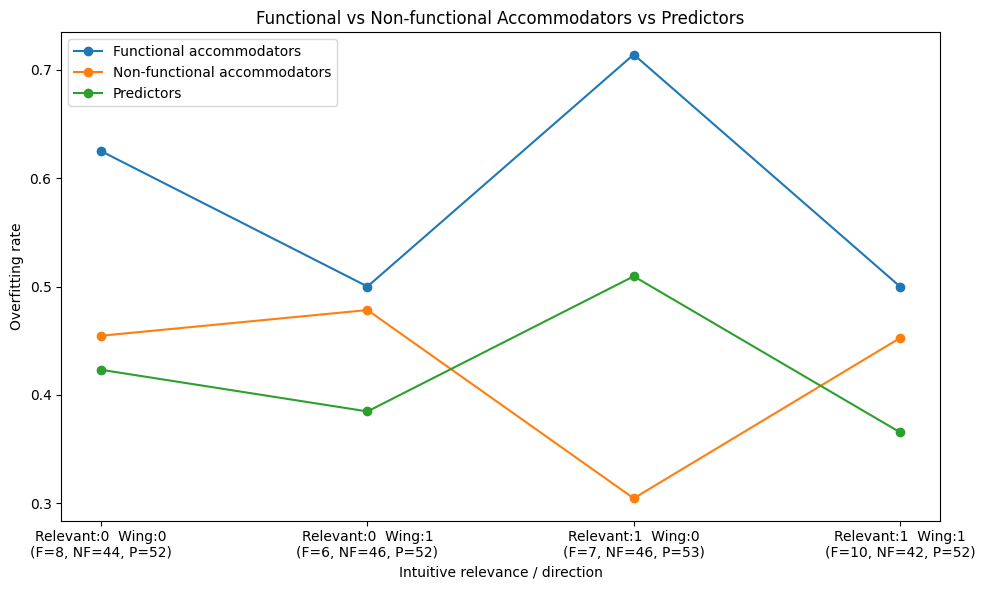

In [260]:
import numpy as np
import matplotlib.pyplot as plt

# --- Subsets ---
func_accom = summary[
    (summary['task'] == 'accommodate') &
    (summary['functional'] == 'functional')
]

nonfunc_accom = summary[
    (summary['task'] == 'accommodate') &
    (summary['functional'] == 'nonfunctional')
]

# X-axis groups
groups = (
    summary_predict[['intuitive_relevance', 'intuitive_direction']]
    .drop_duplicates()
    .sort_values(['intuitive_relevance', 'intuitive_direction'])
    .reset_index(drop=True)
)

x = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(10, 6))

# --- Functional accommodators ---
y_func, n_func = [], []
for _, g in groups.iterrows():
    row = func_accom[
        (func_accom['intuitive_relevance'] == g['intuitive_relevance']) &
        (func_accom['intuitive_direction'] == g['intuitive_direction'])
    ]
    y_func.append(row['overfit_rate'].iloc[0] if not row.empty else np.nan)
    n_func.append(row['n'].iloc[0] if not row.empty else 0)

ax.plot(x, y_func, marker='o', label='Functional accommodators')

# --- Non-functional accommodators ---
y_nonfunc, n_nonfunc = [], []
for _, g in groups.iterrows():
    row = nonfunc_accom[
        (nonfunc_accom['intuitive_relevance'] == g['intuitive_relevance']) &
        (nonfunc_accom['intuitive_direction'] == g['intuitive_direction'])
    ]
    y_nonfunc.append(row['overfit_rate'].iloc[0] if not row.empty else np.nan)
    n_nonfunc.append(row['n'].iloc[0] if not row.empty else 0)

ax.plot(x, y_nonfunc, marker='o', label='Non-functional accommodators')

# --- Predictors ---
y_pred, n_pred = [], []
for _, g in groups.iterrows():
    row = summary_predict[
        (summary_predict['intuitive_relevance'] == g['intuitive_relevance']) &
        (summary_predict['intuitive_direction'] == g['intuitive_direction'])
    ]
    y_pred.append(row['overfit_rate'].iloc[0] if not row.empty else np.nan)
    n_pred.append(row['n'].iloc[0] if not row.empty else 0)

ax.plot(x, y_pred, marker='o', label='Predictors')

# Axis labels
ax.set_xticks(x)
ax.set_xticklabels([
    f"Relevant:{r}  Wing:{d}\n(F={nf}, NF={nnf}, P={np})"
    for r, d, nf, nnf, np in zip(
        groups['intuitive_relevance'],
        groups['intuitive_direction'],
        n_func,
        n_nonfunc,
        n_pred
    )
])

ax.set_ylabel("Overfitting rate")
ax.set_xlabel("Intuitive relevance / direction")
ax.set_title("Functional vs Non-functional Accommodators vs Predictors")
ax.legend()

plt.tight_layout()
plt.show()

In [278]:
import statsmodels.formula.api as smf

df_params['task3'] = np.select(
    [
        (df_params['task'] == 'predict'),
        (df_params['task'] == 'accommodate') & (df_params['functional'] == 'functional'),
        (df_params['task'] == 'accommodate') & (df_params['functional'] == 'nonfunctional')
    ],
    ['predictor', 'acc_functional', 'acc_nonfunctional'], 
    default='other'
)

model = smf.logit(
    formula="""
        overfit ~ task3 * intuitive_relevance * intuitive_direction
    """,
    data=df_params
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.671895
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                overfit   No. Observations:                  418
Model:                          Logit   Df Residuals:                      406
Method:                           MLE   Df Model:                           11
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                 0.01791
Time:                        10:27:43   Log-Likelihood:                -280.85
converged:                       True   LL-Null:                       -285.97
Covariance Type:            nonrobust   LLR p-value:                    0.5088
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------

In [ ]:
import statsmodels.formula.api as smf
#Model for above plot
model = smf.logit(
    formula="""
        overfit ~ task * intuitive_relevance * intuitive_direction
    """,
    data=df_params
).fit()

results_df = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "z": model.tvalues,
    "p_value": model.pvalues,
    "conf_low": model.conf_int()[0],
    "conf_high": model.conf_int()[1]
})

# Save to CSV
results_df.to_csv(os.path.join(outputdir, "Figure2OverfittingRatebyTaskStats.csv"))

In [261]:
#Create map from short codes to feature descriptions

wing_map = {
    'wings': 't',
    'paws': 'n'
}

color_map = {
    'blue': 'b',
    'yellow': 'y'
}

tail_map = {
    'curly': 'c',
    'straight': 's'
}


feature_maps = {
    'wing': wing_map,
    'color': color_map,
    'tail': tail_map
}
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['wing', 'color', 'tail']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        
        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
if debug:
    print(df_combined['wing_importance'])

response: 'paws' internal: 'n' high: 'n' low: 't'
response: 'paws' internal: 'n' high: 'n' low: 't'
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'paws' internal: 'n' high: 'n' low: 't'
response: 'paws' internal: 'n' high: 'n' low: 't'
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'paws' internal: 'n' high: 't' low: 'n'
in negative
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'paws' internal: 'n' high: 't' low: 'n'
in negative
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'paws' internal: 'n' high: 'n' low: 't'
response: 'wings' internal: 't' high: 'n' low: 't'
in negative
response: 'paws' internal: 'n' high: 't' low: 'n'
in negative
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'wings' internal: 't' high: 'n' low: 't'
in negative
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'wings' internal: 't' high: 't' low: 'n'
response: 'paws' internal: 'n'

In [262]:
print(df_combined[['participant', 'task', 'wing_importance', 'color_importance', 'tail_importance', 'functional']])

     participant         task  wing_importance  color_importance  \
0              1  accommodate              6.0               6.0   
1              2  accommodate              6.0               3.0   
2              3  accommodate              0.0               0.0   
3              4  accommodate              5.0               0.0   
4              5  accommodate              7.0              -7.0   
..           ...          ...              ...               ...   
413          414      predict              0.0               6.0   
414          415      predict              0.0               6.0   
415          416      predict              0.0               0.0   
416          417      predict              5.0               6.0   
417          418      predict              0.0               5.0   

     tail_importance     functional  
0                7.0     functional  
1                0.0     functional  
2                7.0     functional  
3                0.0  nonfuncti

In [264]:
# Columns to keep for melting
cols_to_keep = [
    'participant', 'task', 'functional', 
    'wing_importance', 'color_importance', 'tail_importance',
    'relevant_dim_1', 'relevant_dim_2', 'irrelevant_dim',
    'wing_high','wing_discrete_slider.response'
]

df_long = df_combined[cols_to_keep].melt(
    id_vars=['participant','task','functional','relevant_dim_1','relevant_dim_2','irrelevant_dim','wing_high','wing_discrete_slider.response'],
    value_vars=['wing_importance','color_importance','tail_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

# Feature relevance
df_long['feature_relevance'] = df_long.apply(
    lambda row: 'relevant' if row['feature_dimension'] in [row['relevant_dim_1'], row['relevant_dim_2']] else 'irrelevant',
    axis=1
)

print(df_long.tail(10))

      participant     task functional relevant_dim_1 relevant_dim_2  \
1244          409  predict        NaN           tail           wing   
1245          410  predict        NaN           tail          color   
1246          411  predict        NaN           tail          color   
1247          412  predict        NaN           wing          color   
1248          413  predict        NaN           wing          color   
1249          414  predict        NaN          color           wing   
1250          415  predict        NaN           tail          color   
1251          416  predict        NaN          color           tail   
1252          417  predict        NaN          color           tail   
1253          418  predict        NaN          color           tail   

     irrelevant_dim wing_high wing_discrete_slider.response feature_dimension  \
1244          color         T                           Yes              tail   
1245           wing         N                           

In [265]:
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int) #Code having a wing as 0/1
print(df_wing)

     participant         task     functional relevant_dim_1 relevant_dim_2  \
0              1  accommodate     functional           tail          color   
1              2  accommodate     functional          color           wing   
2              3  accommodate     functional          color           tail   
3              4  accommodate  nonfunctional          color           tail   
4              5  accommodate  nonfunctional          color           tail   
..           ...          ...            ...            ...            ...   
413          414      predict            NaN          color           wing   
414          415      predict            NaN           tail          color   
415          416      predict            NaN          color           tail   
416          417      predict            NaN          color           tail   
417          418      predict            NaN          color           tail   

    irrelevant_dim  wing_high wing_discrete_slider.response fea

In [ ]:
import matplotlib.pyplot as plt
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int) #Code relevancy as 0/1
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int) #Code having a wing as 0/1
print(df_wing)
tasks = df_wing['task'].unique()
wing_high_states = df_wing['wing_high'].unique()

fig, axes = plt.subplots(
    nrows=len(wing_high_states),
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4 * len(wing_high_states)),
    sharey=True,
    sharex=True
)

# Handle case where rows/cols == 1
if len(wing_high_states) == 1:
    axes = [axes]

for row, wing_high in enumerate(wing_high_states):
    for col, task in enumerate(tasks):
        ax = axes[row][col] if len(tasks) > 1 else axes[row]

        for label in ['relevant', 'irrelevant']:
            values = df_wing.loc[
                (df_wing['task'] == task) &
                (df_wing['wing_high'] == wing_high) &
                (df_wing['feature_relevance'] == label),
                'feature_importance'
            ]
            
            ax.hist(values, bins=10, alpha=0.6, density=True, label=label)

        ax.set_title(f"{task} | wing high: {wing_high}")
        ax.set_xlabel("Feature importance")
        ax.legend()

axes[0][0].set_ylabel("Density")

plt.tight_layout()
plt.show()

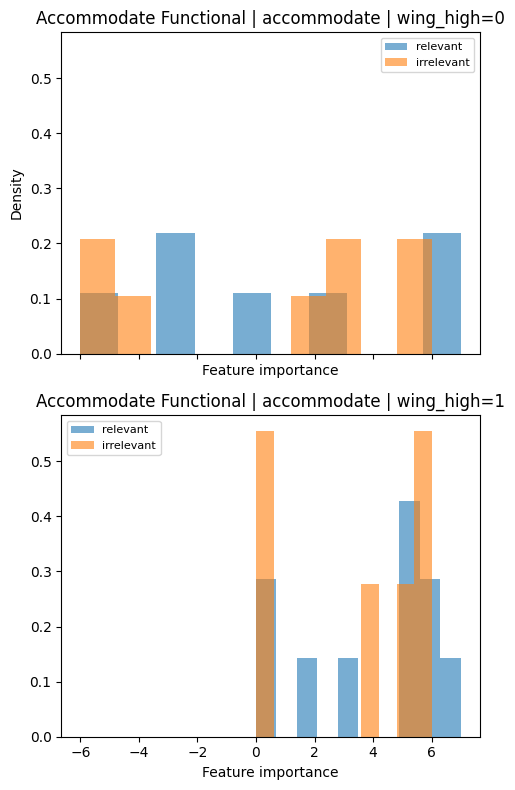

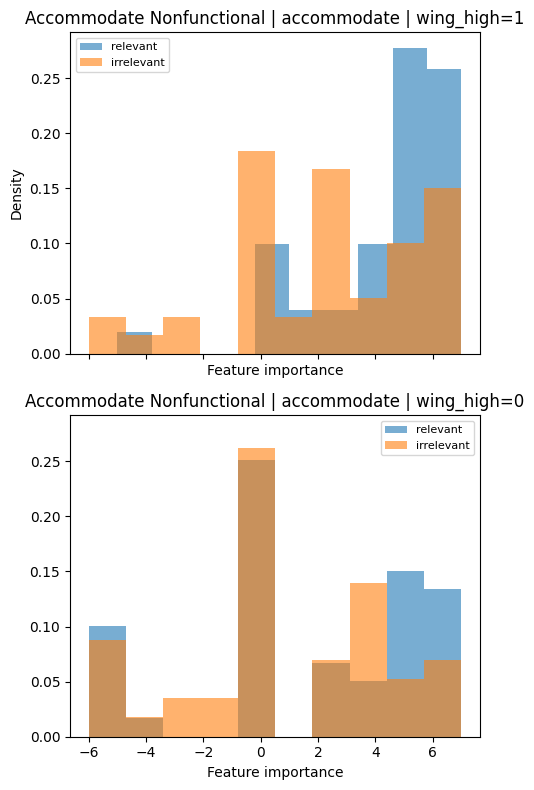

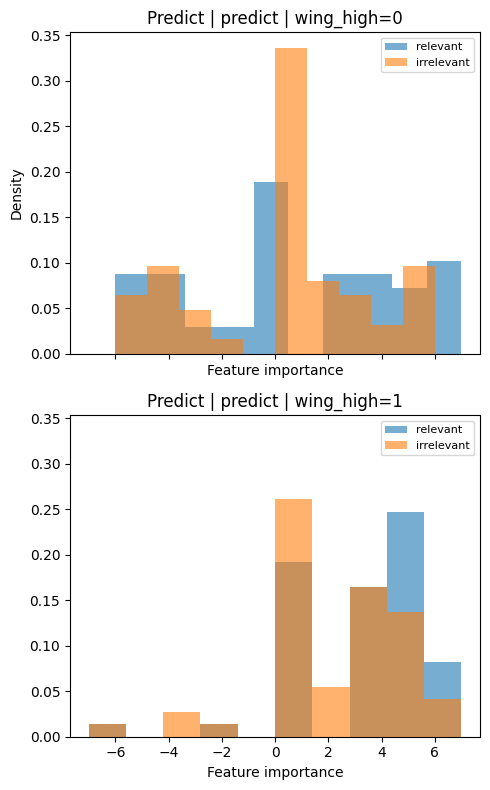

In [268]:
import matplotlib.pyplot as plt
import numpy as np

# Focus on wing
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int)
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int)

# Function to plot faceted by wing_high and task
def plot_wing_histograms(subset, title_prefix):
    tasks = subset['task'].unique()
    wing_high_states = subset['wing_high'].unique()
    
    fig, axes = plt.subplots(
        nrows=len(wing_high_states),
        ncols=len(tasks),
        figsize=(5 * len(tasks), 4 * len(wing_high_states)),
        sharex=True,
        sharey=True
    )

    if len(wing_high_states) == 1:
        axes = np.array([axes])
    if len(tasks) == 1:
        axes = axes.reshape(len(wing_high_states), 1)

    for row, wh in enumerate(wing_high_states):
        for col, task in enumerate(tasks):
            ax = axes[row][col]
            for label in ['relevant', 'irrelevant']:
                values = subset.loc[
                    (subset['task'] == task) &
                    (subset['wing_high'] == wh) &
                    (subset['feature_relevance'] == label),
                    'feature_importance'
                ]
                if not values.empty:
                    ax.hist(values, bins=10, alpha=0.6, density=True, label=label)
            ax.set_title(f"{title_prefix} | {task} | wing_high={wh}")
            ax.set_xlabel("Feature importance")
            ax.legend(fontsize=8)

    axes[0][0].set_ylabel("Density")
    plt.tight_layout()
    plt.show()

# --- Plot functional accommodators ---
df_func_accom = df_wing[(df_wing['task'] == 'accommodate') & (df_wing['functional'] == 'functional')]
plot_wing_histograms(df_func_accom, "Accommodate Functional")

# --- Plot nonfunctional accommodators ---
df_nonfunc_accom = df_wing[(df_wing['task'] == 'accommodate') & (df_wing['functional'] == 'nonfunctional')]
plot_wing_histograms(df_nonfunc_accom, "Accommodate Nonfunctional")

# --- Plot predictors ---
df_predict = df_wing[df_wing['task'] == 'predict']
plot_wing_histograms(df_predict, "Predict")

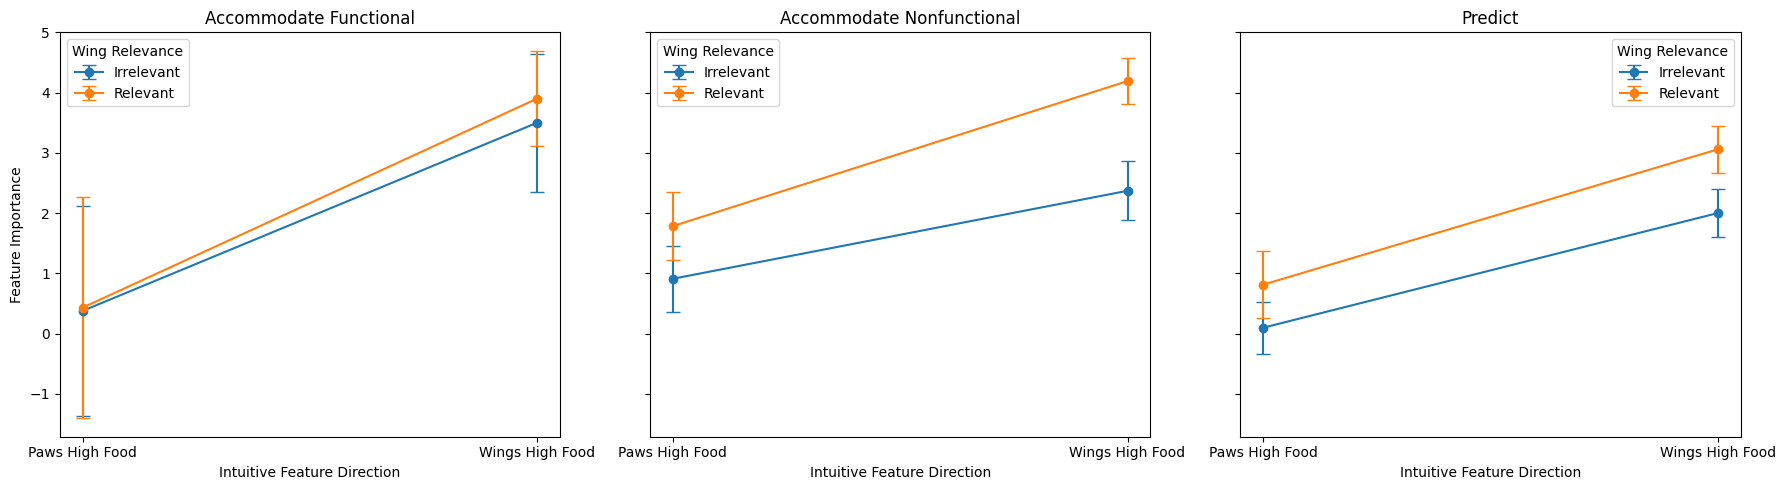

In [271]:
import matplotlib.pyplot as plt
import numpy as np

# Focus on wing feature
df_wing = df_long[df_long["feature_dimension"] == "wing"].copy()
df_wing["wing_relevant"] = (df_wing["feature_relevance"] == "relevant").astype(int)
df_wing["wing_high"] = (df_wing["wing_high"] == "T").astype(int)

# Define the datasets to plot
plot_groups = [
    ("Accommodate Functional", df_wing[(df_wing["task"] == "accommodate") & (df_wing["functional"] == "functional")]),
    ("Accommodate Nonfunctional", df_wing[(df_wing["task"] == "accommodate") & (df_wing["functional"] == "nonfunctional")]),
    ("Predict", df_wing[df_wing["task"] == "predict"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 3 plots side by side

for ax, (title, subset) in zip(axes, plot_groups):
    for rel in [0, 1]:  # irrelevant / relevant
        rel_df = subset[subset["wing_relevant"] == rel]

        means = []
        ses = []

        for present in [0, 1]:  # wing_high = 0 / 1
            cell = rel_df[rel_df["wing_high"] == present]["feature_importance"]
            means.append(cell.mean() if len(cell) > 0 else np.nan)
            ses.append(cell.std() / np.sqrt(len(cell)) if len(cell) > 0 else 0)

        label = "Relevant" if rel == 1 else "Irrelevant"
        ax.errorbar([0, 1], means, yerr=ses, marker='o', capsize=5, label=label)

    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Paws High Food", "Wings High Food"])
    ax.set_xlabel("Intuitive Feature Direction")
    ax.legend(title="Wing Relevance")

axes[0].set_ylabel("Feature Importance")  # Only first subplot gets y-label

plt.tight_layout()
plt.show()

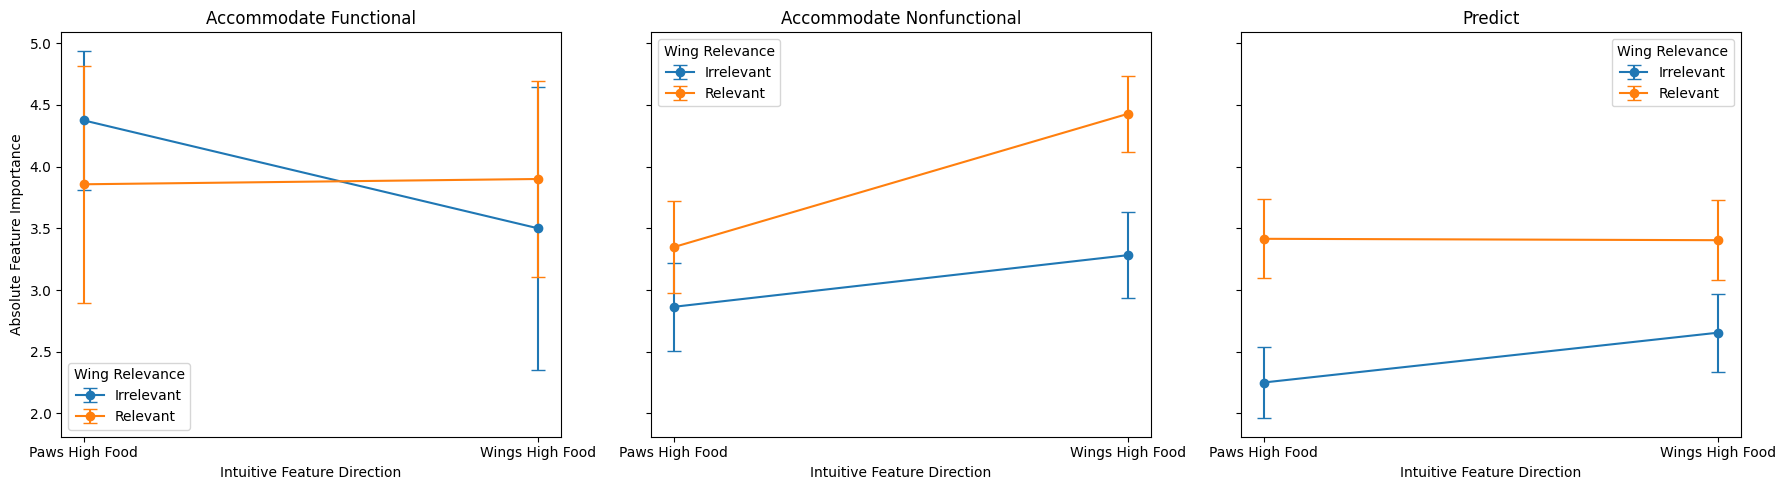

In [272]:
df_wingAbs = df_wing.copy()
df_wingAbs["abs_feature_importance"] = df_wingAbs["feature_importance"].abs()


# Define the datasets to plot
plot_groups = [
    ("Accommodate Functional", df_wingAbs[(df_wingAbs["task"] == "accommodate") & (df_wingAbs["functional"] == "functional")]),
    ("Accommodate Nonfunctional", df_wingAbs[(df_wingAbs["task"] == "accommodate") & (df_wingAbs["functional"] == "nonfunctional")]),
    ("Predict", df_wingAbs[df_wingAbs["task"] == "predict"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 3 plots side by side

for ax, (title, subset) in zip(axes, plot_groups):
    for rel in [0, 1]:  # irrelevant / relevant
        rel_df = subset[subset["wing_relevant"] == rel]

        means = []
        ses = []

        for present in [0, 1]:  # wing_high = 0 / 1
            cell = rel_df[rel_df["wing_high"] == present]["abs_feature_importance"]
            means.append(cell.mean() if len(cell) > 0 else np.nan)
            ses.append(cell.std() / np.sqrt(len(cell)) if len(cell) > 0 else 0)

        label = "Relevant" if rel == 1 else "Irrelevant"
        ax.errorbar([0, 1], means, yerr=ses, marker='o', capsize=5, label=label)

    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Paws High Food", "Wings High Food"])
    ax.set_xlabel("Intuitive Feature Direction")
    ax.legend(title="Wing Relevance")

axes[0].set_ylabel("Absolute Feature Importance")  # Only first subplot gets y-label

plt.tight_layout()
plt.show()